# Agentic RAG

이번 튜토리얼에서는 **에이전트(Agent)** 기반의 RAG 시스템을 구축합니다.

에이전트는 검색 도구를 사용할지 여부를 스스로 결정합니다. 에이전트에 대한 자세한 내용은 [Agent 튜토리얼](https://wikidocs.net/233782)을 참고하세요.

**학습 목표**

- LLM에 검색 도구를 바인딩하여 에이전트를 구성하는 방법을 학습합니다.
- `ToolNode`와 `tools_condition`을 활용한 에이전트 그래프를 구축합니다.
- 문서 관련성 평가 및 쿼리 재작성 흐름을 구현합니다.

![langgraph-agentic-rag](assets/langgraph-agentic-rag.png)

## 환경 설정

API 키와 LangSmith 추적을 설정합니다. `dotenv`를 사용하여 환경 변수를 로드하고, `langchain_teddynote`의 로깅 기능으로 LangSmith 추적을 활성화합니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-RAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-RAG


## PDF 기반 Retrieval Chain 생성

에이전트가 검색할 문서를 준비합니다. `PDFRetrievalChain`을 사용하여 PDF 파일을 로드하고, 벡터 기반의 Retriever와 RAG Chain을 생성합니다. 이 Retriever는 이후 에이전트의 검색 도구로 활용됩니다.

아래 코드는 PDF 문서를 로드하고 Retriever와 Chain을 생성합니다.

In [3]:
from rag.pdf import PDFRetrievalChain

# PDF 문서를 로드합니다.
pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

# retriever와 chain을 생성합니다.
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

Cache configured for multi-PDF processing
Loading PDF: data/SPRI_AI_Brief_2023년12월호_F.pdf
Successfully loaded 23 pages from: data/SPRI_AI_Brief_2023년12월호_F.pdf

Loading Summary:
- Successfully loaded: 1 files
- Failed to load: 0 files
- Total documents loaded: 23
FAISS index saved to cache


## 검색 도구 생성

`create_retriever_tool`을 사용하여 Retriever를 에이전트가 호출할 수 있는 도구(Tool)로 변환합니다. 에이전트는 질문에 따라 이 도구를 호출할지 여부를 스스로 판단합니다. `document_prompt`를 설정하면 검색된 문서의 출력 형식을 지정할 수 있습니다.

**`document_prompt` 사용 가능한 키**

- `page_content`: 문서 내용
- `source`: 문서 출처
- `page`: 페이지 번호

아래 코드는 PDF Retriever를 도구로 변환하고 도구 리스트에 추가합니다.

In [4]:
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.prompts import PromptTemplate

# PDF 문서 검색 도구 생성
retriever_tool = create_retriever_tool(
    pdf_retriever,
    "pdf_retriever",
    "Search and return information about SPRI AI Brief PDF file. It contains useful information on recent AI trends. The document is published on Dec 2023.",
    document_prompt=PromptTemplate.from_template(
        "<document><context>{page_content}</context><metadata><source>{source}</source><page>{page}</page></metadata></document>"
    ),
)

# 도구 리스트에 추가
tools = [retriever_tool]

## Agent State 정의

에이전트의 상태(State)를 정의합니다. Agentic RAG에서는 `messages` 리스트가 핵심 상태로, 사용자 질문, 에이전트 응답, 도구 호출 결과 등 모든 메시지가 이 리스트에 누적됩니다. `add_messages` 리듀서를 적용하면 새 메시지가 기존 리스트를 덮어쓰지 않고 추가됩니다.

아래 코드는 메시지 리스트를 관리하는 `AgentState` 타입을 정의합니다.

In [5]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


# 에이전트 상태 정의 (TypedDict 기반 - LangGraph v1 호환)
class AgentState(TypedDict):
    # add_messages 리듀서를 사용하여 메시지 시퀀스 관리
    messages: Annotated[list[BaseMessage], add_messages]

## 노드와 엣지

에이전트 기반 RAG 그래프는 다음과 같이 구성됩니다.

- **상태**: 메시지들의 집합
- **노드**: 상태를 업데이트(추가)
- **조건부 엣지**: 다음에 방문할 노드를 결정

### 문서 평가기(Grader) 및 노드 정의

이 셀에서는 Agentic RAG 그래프의 핵심 함수 4개를 정의합니다.

- **`grade_documents`**: 검색된 문서가 질문과 관련이 있는지 평가하여 `generate` 또는 `rewrite`로 라우팅하는 조건부 엣지 함수입니다.
- **`agent`**: LLM에 도구를 바인딩하여 검색 도구 호출 여부를 결정하는 노드입니다.
- **`rewrite`**: 검색 결과가 관련 없을 때 질문을 재작성하는 노드입니다.
- **`generate`**: 검색된 문서를 컨텍스트로 사용하여 최종 답변을 생성하는 노드입니다.

아래 코드는 문서 관련성 평가 모델과 3개의 노드 함수, 1개의 라우팅 함수를 정의합니다.

In [6]:
from typing import Literal
from langsmith import Client
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import tools_condition

# LangSmith 클라이언트 초기화 (프롬프트 허브 사용)
ls_client = Client()

# 사용할 모델을 정의합니다.
# OpenAI 키를 사용하는 경우 gpt-4.1-mini, gpt-5.2 등으로 변경하세요
MODEL_NAME = "claude-sonnet-4-5"


# 관련성 평가를 위한 데이터 모델
class GradeDocuments(BaseModel):
    """검색된 문서의 관련성을 평가하는 이진 점수입니다."""

    binary_score: str = Field(
        description="문서가 질문과 관련이 있으면 'yes', 없으면 'no'"
    )


def grade_documents(state) -> Literal["generate", "rewrite"]:
    """검색된 문서의 관련성을 평가하는 함수입니다."""
    # LLM 초기화
    model = init_chat_model(MODEL_NAME, temperature=0)

    # 구조화된 출력을 위한 LLM 설정
    llm_with_tool = model.with_structured_output(GradeDocuments)

    # 프롬프트 템플릿 정의
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # 체인 생성
    chain = prompt | llm_with_tool

    # 현재 상태에서 메시지 추출
    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content
    retrieved_docs = last_message.content

    # 관련성 평가 실행
    scored_result = chain.invoke({"question": question, "context": retrieved_docs})
    score = scored_result.binary_score

    # 관련성 여부에 따른 결정
    if score == "yes":
        print("==== [DECISION: DOCS RELEVANT] ====")
        return "generate"
    else:
        print("==== [DECISION: DOCS NOT RELEVANT] ====")
        return "rewrite"


def agent(state):
    """에이전트 노드입니다. 도구 사용 여부를 결정합니다."""
    messages = state["messages"]

    # LLM 초기화 및 도구 바인딩
    model = init_chat_model(MODEL_NAME, temperature=0)
    model = model.bind_tools(tools)

    # 에이전트 응답 생성
    response = model.invoke(messages)

    return {"messages": [response]}


def rewrite(state):
    """질문을 재작성하는 노드입니다."""
    print("==== [QUERY REWRITE] ====")
    messages = state["messages"]
    question = messages[0].content

    # 질문 개선을 위한 프롬프트 구성
    msg = [
        HumanMessage(
            content=f"""\n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # LLM으로 질문 개선
    model = init_chat_model(MODEL_NAME, temperature=0)
    response = model.invoke(msg)

    return {"messages": [response]}


def generate(state):
    """답변을 생성하는 노드입니다."""
    messages = state["messages"]
    question = messages[0].content
    docs = messages[-1].content

    # LangSmith 허브에서 RAG 프롬프트 가져오기
    prompt = ls_client.pull_prompt("teddynote/rag-prompt")

    # LLM 초기화 및 체인 구성
    llm = init_chat_model(MODEL_NAME, temperature=0)
    rag_chain = prompt | llm | StrOutputParser()

    # 답변 생성
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

## 그래프 생성

정의한 노드들을 `StateGraph`로 연결하여 에이전트 그래프를 구성합니다. 실행 흐름은 다음과 같습니다.

- `agent` 노드에서 시작하여 도구 호출 여부를 결정합니다.
- 도구를 호출하면 `retrieve` 노드에서 검색을 수행한 후, 조건부 엣지에서 문서 관련성을 평가합니다.
- 관련 문서이면 `generate`에서 답변을 생성하고, 관련 없으면 `rewrite`에서 질문을 재작성한 뒤 다시 `agent`로 돌아갑니다.

아래 코드는 노드와 엣지를 연결하고 그래프를 컴파일합니다.

In [7]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# AgentState 기반 워크플로우 초기화
workflow = StateGraph(AgentState)

# 노드 정의
workflow.add_node("agent", agent)  # 에이전트 노드
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)  # 검색 노드
workflow.add_node("rewrite", rewrite)  # 질문 재작성 노드
workflow.add_node("generate", generate)  # 답변 생성 노드

# 엣지 연결
workflow.add_edge(START, "agent")

# 검색 여부 결정을 위한 조건부 엣지
workflow.add_conditional_edges(
    "agent",
    tools_condition,  # 에이전트 결정 평가
    {
        "tools": "retrieve",  # 도구 호출 -> 검색
        END: END,  # 도구 미호출 -> 종료
    },
)

# 검색 후 문서 평가를 위한 조건부 엣지
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,  # 문서 품질 평가
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# 그래프 컴파일
graph = workflow.compile(checkpointer=MemorySaver())

### 그래프 시각화

컴파일된 그래프의 노드 구조와 엣지 연결을 시각적으로 확인합니다. `visualize_graph`를 사용하면 각 노드 간의 흐름과 조건부 분기를 한눈에 파악할 수 있습니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

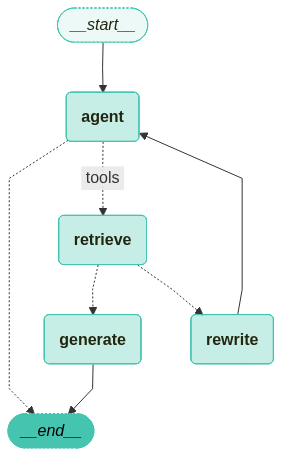

In [8]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

## 그래프 실행

구성한 Agentic RAG 그래프를 실행합니다. `invoke_graph`는 전체 실행 결과를 노드별로 출력하고, `stream_graph`는 실시간 스트리밍으로 출력합니다. `config`에 `thread_id`를 지정하면 동일 스레드 내에서 대화 이력이 유지됩니다.

아래 코드는 문서 검색이 필요한 질문으로 그래프를 실행합니다.

In [9]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, invoke_graph, random_uuid

# config 설정
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# 문서 검색이 필요한 질문
inputs = {
    "messages": [
        ("user", "삼성전자가 개발한 생성형 AI 의 이름은?"),
    ]
}

# 그래프 실행
invoke_graph(graph, inputs, config)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'id': 'toolu_01WeNQmTrXRiSKgLsHcZHSTz', 'input': {'query': '삼성전자 생성형 AI'}, 'name': 'pdf_retriever', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  pdf_retriever (toolu_01WeNQmTrXRiSKgLsHcZHSTz)
 Call ID: toolu_01WeNQmTrXRiSKgLsHcZHSTz
  Args:
    query: 삼성전자 생성형 AI
==== [DECISION: DOCS RELEVANT] ====

🔄 Node: retrieve 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: pdf_retriever

<document><context>SPRi AI Brief |
2023-12월호
삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개
KEY Contents
n 삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성
AI 모델 ‘삼성 가우스’를 공개
n 삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획으로, 온디바이스 작동이 가능한
삼성 가우스는 외부로 사용자 정보가 유출될 위험이 없다는 장점을 보유
£언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원
n 삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’ 행사에서 자체 개발한 생

In [10]:
# 그래프 스트리밍 출력
stream_graph(graph, inputs, config, node_names=["agent", "rewrite", "generate"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
삼성전자가 개발한 생성형 AI의 이름은 **'삼성 가우스(Samsung Gauss)'**입니다.

**주요 특징:**
- 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본떠 명명
- 2023년 11월 8일 '삼성 AI 포럼 2023'에서 최초 공개
- **언어 모델, 코드 모델, 이미지 모델**의 3개 모델로 구성
- **온디바이스(On-device)** 작동 지원으로 외부로 사용자 정보가 유출될 위험이 없음
- 다양한 상황에 최적화된 크기의 모델 선택 가능

**구성 모델:**
1. **언어 모델**: 메일 작성, 문서 요약, 번역 업무 지원
2. **코드 모델**: AI 코딩 어시스턴트 '코드아이(code.i)' 제공
3. **이미지 모델**: 이미지 생성 및 편집, 저해상도 이미지의 고해상도 전환 지원

삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획입니다.

### 문서 검색이 불필요한 질문 예시

에이전트는 질문 내용에 따라 검색 도구 호출 여부를 스스로 판단합니다. PDF 문서와 관련 없는 일반 상식 질문의 경우, 에이전트가 도구를 호출하지 않고 LLM의 내장 지식으로 직접 답변합니다.

아래 코드는 문서 검색 없이 에이전트가 직접 답변하는 예시입니다.

In [11]:
# 문서 검색이 불필요한 질문 예시
inputs = {
    "messages": [
        ("user", "대한민국의 수도는?"),
    ]
}

# 그래프 실행
stream_graph(graph, inputs, config, node_names=["agent", "rewrite", "generate"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
대한민국의 수도는 **서울특별시**입니다.

서울은 대한민국의 정치, 경제, 사회, 문화의 중심지이며, 약 1천만 명의 인구가 거주하는 대도시입니다.

참고로, 이 질문은 제가 가진 SPRI AI Brief PDF 문서의 내용과는 관련이 없는 일반 상식 질문입니다. AI 관련 동향이나 기술에 대해 궁금하신 점이 있으시면 언제든지 질문해 주세요!

### 재귀 한계 처리

문서에 존재하지 않는 내용을 검색하도록 유도하면, 에이전트가 검색 → 관련성 없음 → 재작성 → 재검색 루프를 반복하게 됩니다. 이 경우 `recursion_limit`에 도달하면 `GraphRecursionError`가 발생합니다. 실제 서비스에서는 이 에러를 적절히 처리하여 사용자에게 안내 메시지를 반환해야 합니다.

아래 코드는 PDF에 없는 내용을 질문하여 `GraphRecursionError`가 발생하는 상황을 시연합니다.

In [13]:
from langgraph.errors import GraphRecursionError

# 새로운 thread_id로 config 생성 (이전 대화 기록 초기화)
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# PDF 문서에 없는 내용을 PDF에서 찾도록 유도하는 질문
# 에이전트가 검색 도구를 반복 호출하지만, 관련 문서를 찾지 못해 재작성을 반복합니다.
inputs = {
    "messages": [
        ("user", "SPRI AI Brief 문서에서 소개된 테디노트의 랭체인 튜토리얼에 대해서 알려줘"),
    ]
}

try:
    # 그래프 실행
    stream_graph(graph, inputs, config, node_names=["agent", "rewrite", "generate"])
except GraphRecursionError as recursion_error:
    print(f"GraphRecursionError: {recursion_error}")


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [DECISION: DOCS NOT RELEVANT] ====
==== [QUERY REWRITE] ====

🔄 Node: rewrite 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Looking at this question, I can identify the following key elements:

**Semantic Intent:**
- The user wants information about a LangChain tutorial by "Teddynote"
- This tutorial was featured/introduced in a document called "SPRI AI Brief"
- The question is in Korean

**Improved Question (in Korean):**

SPRI AI Brief 문서에 소개된 테디노트(Teddynote)의 랭체인(LangChain) 튜토리얼에 대해 다음 내용을 알려주세요:
1. 튜토리얼의 주요 내용과 특징은 무엇인가요?
2. 어떤 주제들을 다루고 있나요?
3. SPRI AI Brief에서 이 튜토리얼을 소개한 맥락이나 이유는 무엇인가요?
4. 해당 튜토리얼에 접근할 수 있는 방법이나 링크 정보가 있나요?

**Improved Question (in English):**

Please provide information about Teddynote's LangChain tutorial that was featured in the SPRI AI Brief document, including:
1. What are the main contents and characteristics of the tutorial?
2. What topics does it cover?
3. What was the context 

## 정리

이 튜토리얼에서는 **Agentic RAG** 시스템을 구축했습니다.

### 핵심 개념

1. **Agent**: 도구 사용 여부를 스스로 결정하는 LLM 기반 에이전트입니다.
2. **ToolNode**: 도구를 노드로 래핑하여 그래프에서 사용합니다.
3. **tools_condition**: 에이전트의 도구 호출 결정을 기반으로 라우팅합니다.
4. **문서 평가**: 검색된 문서의 관련성을 평가하여 답변 생성 또는 재검색을 결정합니다.

### 다음 단계

다음 튜토리얼에서는 **CRAG(Corrective RAG)**를 구현하여 검색 결과를 정제하고 웹 검색으로 보강하는 방법을 학습합니다.